#  Model Training


## Generate data

In [2]:
import agama
import torch 
import numpy as np
from astropy import units as u

from sbi.utils import BoxUniform
from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi
from sbi.utils import likelihood_nn

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import pickle

from python_scripts.galaxy_generation import generate_galaxy_multiple
from python_scripts.prior_generation import generate_prior

import corner

torch.set_num_threads(4)


In [3]:
# set agama unit to be in Msun, kpc, km/s
agama.setUnits(mass=1 * u.Msun, length=1*u.kpc, velocity=1 * u.km /u.s)

## Training

In [4]:
agama.setRandomSeed(13)
torch.manual_seed(13)
np.random.seed(13)


### Generating data

In [29]:
prior = generate_prior()
simulator_sbi, prior_sbi = prepare_for_sbi(generate_galaxy_multiple, prior)

In [13]:
#. Generate Training Data
theta_train, x_train = simulate_for_sbi(
    simulator_sbi, prior_sbi, num_simulations=1000, num_workers=1
)
x_train = x_train.squeeze()

Running 1000 simulations.:   0%|          | 0/1000 [00:00<?, ?it/s]

#### Generating 10000 data then saving to csv

In [7]:
prior = generate_prior()

In [51]:
theta = prior.sample((10000,))
df = pd.DataFrame(np.repeat(theta, 100, axis=0))
df.to_csv("./data/training_theta.csv", index=False, header=False)

In [52]:
x = generate_galaxy_multiple(theta, 100).numpy()
out = x.reshape(x.shape[0] * x.shape[1], x.shape[2])
df = pd.DataFrame(out)

df.to_csv("./data/training_x.csv", index=False, header=False)

#### Generating 10k galaxies, 10 stars

In [16]:
df = np.array(pd.read_csv("./data/training_x(100).csv", header=None))
df= df.reshape((10000, 100, 6))
df = df[:, :10, :]
df = pd.DataFrame(df.reshape((100000, 6)))
df.to_csv("./data/training_x(10).csv", index=False, header=False)

In [18]:
df = np.array(pd.read_csv("./data/training_theta(100).csv", header=None))
df= df.reshape((10000, 100, 4))
df = df[:, :10, :]
df = pd.DataFrame(df.reshape((100000, 4)))
df.to_csv("./data/training_theta(10).csv", index=False, header=False)


#### Poisson distribution

In [70]:
prior = generate_prior()
thetas = prior.sample((10000,))

n_list = []
output_x = []

for row in thetas:
    r = row.reshape((1,4))
    n = np.random.poisson(100)
    n_list.append(n)
    
    xs = generate_galaxy_multiple(r, n_stars=n)
    output_x.append(xs)
    
theta = torch.repeat_interleave(thetas, torch.tensor(n_list), dim=0)
x = torch.cat(output_x, dim=1).squeeze()
    



In [71]:
pd.DataFrame(theta).to_csv("./data/training_theta(poisson).csv", header=False, index=False)
pd.DataFrame(x).to_csv("./data/training_x(poisson).csv", header=False, index=False)

#### Test samples

In [72]:
prior = generate_prior()
thetas = prior.sample((1000,))

n_list = []
output_x = []

for row in thetas:
    r = row.reshape((1,4))
    n = np.random.poisson(100)
    n_list.append(n)
    
    xs = generate_galaxy_multiple(r, n_stars=n)
    output_x.append(xs)
    
theta = torch.repeat_interleave(thetas, torch.tensor(n_list), dim=0)
x = torch.cat(output_x, dim=1).squeeze()
    
pd.DataFrame(theta).to_csv("./data/test_theta.csv", header=False, index=False)
pd.DataFrame(x).to_csv("./data/test_x.csv", header=False, index=False)


### Train the model

#### Single star per galaxy

In [10]:
theta_train = torch.from_numpy(np.array(pd.read_csv("./data/training_theta(100).csv", header=None))).float()[:10000]
x_train = torch.from_numpy(np.array(pd.read_csv("./data/training_x(100).csv", header=None))).float()[:10000]

In [11]:
torch.set_num_threads(4)
prior_sbi = generate_prior()

density_estimator =likelihood_nn(model="nsf", 
                                 hidden_features = 104,
                                 num_transforms = 7,
                                 num_bins = 6)

inference = SNLE(prior=prior_sbi, density_estimator=density_estimator)
inference.append_simulations(theta_train, x_train)
arg = {
        "training_batch_size": 1024,
        "learning_rate": 0.001347,
        "validation_fraction": 0.1,
        "stop_after_epochs": 10,
        "max_num_epochs": 2^31 - 1,
        "clip_max_norm": 5.0,
        "resume_training": False,
        "discard_prior_samples": False,
        "retrain_from_scratch": False,
        "show_train_summary": True,
        "dataloader_kwargs": {"num_workers": 2, 
                                "persistent_workers": True}
}

likelihood_estimator = inference.train(**arg)

# lr: 0.001347, tbs: 512

 Training neural network. Epochs trained: 18

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6ed60c2af0><function _MultiProcessingDataLoaderIter.__del__ at 0x7a6ed60c2af0>

Traceback (most recent call last):
  File "/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
Traceback (most recent call last):
      File "/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
self._shutdown_workers()
      File "/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
self._shutdown_workers()
      File "/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
if w.is_alive():
      File "/home/tingli/anaconda3/envs/myenv/lib/python3.9/multiprocessing/process.py", line 160, in is_alive
if w.is_alive():    
assert self._parent

 Training neural network. Epochs trained: 29
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 29
        Best validation performance: -8.9574
        -------------------------
        


In [16]:
inference._summary["best_validation_log_prob"]

[-8.152990356445313]

### Pickle

In [ ]:


posterior = inference.build_posterior(likelihood_estimator, mcmc_method="slice_np_vectorized")

with open("./model/posterior.pkl", "wb") as handle:
    pickle.dump(posterior, handle)


In [125]:
with open("./model/likelihood_estimator(poisson).pkl", "wb") as handle:
    pickle.dump(likelihood_estimator, handle)

In [126]:
with open("./model/inference.pkl(poisson)", "wb") as handle:
    pickle.dump(inference, handle)

/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/inference/base.py:429: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  warn(


In [ ]:

with open('./model/posterior.pkl', 'rb') as file:
    # Load the object from the file
    posterior = pickle.load(file)

### Hyperparameter tuning

In [ ]:
import optuna   

In [ ]:
# outdated

def objective(trial):
        
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    training_batch_size = trial.suggest_categorical("training_batch_size", [32, 64, 128, 256, 512, 1024, 2048])
    
    
    theta_train = torch.from_numpy(np.array(pd.read_csv("./data/training_theta.csv", header=None))).float()
    x_train = torch.from_numpy(np.array(pd.read_csv("./data/training_x.csv", header=None))).float() 
    
    prior_sbi = generate_prior()
    inference = SNLE(prior=prior_sbi)
    inference.append_simulations(theta_train, x_train)
    
    likelihood_estimator = inference.train(learning_rate = learning_rate,
                                           training_batch_size = training_batch_size,
                                           stop_after_epochs = 10,
    )
    
    return inference._summary["best_validation_log_prob"][0]

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=2)

import pickle
with open("./model/tune.pkl", "wb") as handle:
    pickle.dump(study, handle)
    
print(study.best_params)


[I 2026-05-19 09:25:52,851] A new study created in memory with name: no-name-ca9aa964-5828-4182-bfd7-5129bfa15e72


 Training neural network. Epochs trained: 109

[I 2026-05-19 09:41:45,440] Trial 0 finished with value: -7.2913370289522055 and parameters: {'learning_rate': 0.00046936482650969613, 'training_batch_size': 425, 'stop_after_epochs': 20}. Best is trial 0 with value: -7.2913370289522055.


 Training neural network. Epochs trained: 160110 epochs.

[I 2026-05-19 10:04:58,854] Trial 1 finished with value: -8.581448269873551 and parameters: {'learning_rate': 6.218574263473771e-05, 'training_batch_size': 388, 'stop_after_epochs': 20}. Best is trial 0 with value: -7.2913370289522055.


 Neural network successfully converged after 161 epochs.

In [37]:
with open('./model/inference(poisson).pkl', 'rb') as file:
    # Load the object from the file
    k = pickle.load(file)

In [38]:
k._summary["best_validation_log_prob"]

[-7.589549103761331]

Optuna results

In [33]:

with open('./model/tune(poisson_d_20k).pkl', 'rb') as file:
    # Load the object from the file
    result = pickle.load(file)

In [32]:
# import optuna
# import matplotlib.pyplot as plt
# optuna.visualization.plot_optimization_history(result)

In [34]:
result.best_params

{'learning_rate': 0.00482659821806299,
 'training_batch_size': 1024,
 'hidden_features': 96,
 'num_transforms': 8,
 'num_bins': 7}

## MCMC

#### MCMCPosterior

In [4]:
from sbi.inference import likelihood_estimator_based_potential, MCMCPosterior


In [114]:
import gc
def generate_samples(x_o, likelihood_estimator, prior, n_samples):
    """
    generate sample for single observed x (perhaps with multiple stars, but generated from same theta)

    - x_o: observed universe
    - n_samples: number of samples to generate
    """
    potential_fn, parameter_transform = likelihood_estimator_based_potential(
    likelihood_estimator, prior, x_o
)
    posterior = MCMCPosterior(
    potential_fn, proposal=prior, 
    theta_transform=parameter_transform, 
    warmup_steps=200,
    num_chains=8,
    num_workers= 4,
    method = "slice_np_vectorized"
    )

    samples = posterior.sample((n_samples,))

    del posterior
    del potential_fn
    del parameter_transform
    
    gc.collect()
    
    return samples



In [6]:
with open('./model/likelihood_estimator.pkl', 'rb') as file:
    # Load the object from the file
    likelihood_estimator = pickle.load(file)

In [7]:
test_theta_raw = np.array(pd.read_csv("./data/test_theta.csv", header=None))
test_x_raw = np.array(pd.read_csv("./data/test_x.csv", header=None))


In [8]:
test_theta, index = np.unique(test_theta_raw, axis=0, return_index=True)

index = np.sort(index)

test_x = np.split(test_x_raw, index, axis=0)[1:]

Parallel

In [111]:
from joblib import Parallel, delayed

torch.set_num_threads(1)

results = Parallel(n_jobs=4)(
    delayed(generate_samples)(x_o, likelihood_estimator, prior, 1000) for x_o in test_x
)

samples = np.array(results)

/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/utils/sbiutils.py:316: UserWarning: An x with a batch size of 99 was passed. It will be interpreted as a batch of independent and identically
            distributed data X={x_1, ..., x_n}, i.e., data generated based on the
            same underlying (unknown) parameter. The resulting posterior will be with
            respect to entire batch, i.e,. p(theta | X).
  warnings.warn(
/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/utils/sbiutils.py:316: UserWarning: An x with a batch size of 104 was passed. It will be interpreted as a batch of independent and identically
            distributed data X={x_1, ..., x_n}, i.e., data generated based on the
            same underlying (unknown) parameter. The resulting posterior will be with
            respect to entire batch, i.e,. p(theta | X).
  warnings.warn(
Generating 8 MCMC inits with 4
                         workers.:   0%|          | 0/8 [00:00<?, ?i

KeyboardInterrupt: 

Single

In [116]:
prior = generate_prior()
generate_samples(test_x[0][:10], likelihood_estimator, prior, 100)

Generating 8 MCMC inits with 4
                         workers.:   0%|          | 0/8 [00:00<?, ?it/s]

Running vectorized MCMC with 8 chains:   0%|          | 0/17000 [00:00<?, ?it/s]

tensor([[ 6.0925e+00, -3.1869e-01,  1.9667e+00,  5.3171e-01],
        [ 6.4727e+00, -4.2108e-01,  1.3913e+00,  6.4648e-01],
        [ 6.7441e+00, -1.7273e-01,  6.8170e-01,  4.8886e-01],
        [ 6.2513e+00, -1.1547e-01,  1.0294e+00,  2.7174e-01],
        [ 6.6323e+00, -1.0816e-01, -1.5306e-02,  5.8456e-01],
        [ 6.9714e+00, -1.6635e-01,  4.6109e-03,  4.1659e-01],
        [ 6.9206e+00, -1.5818e-01, -2.5700e-01,  4.8869e-01],
        [ 6.4594e+00, -2.3753e-01,  7.1250e-01,  4.3944e-01],
        [ 6.3177e+00, -1.2114e-01,  1.1560e+00,  3.3567e-01],
        [ 6.1063e+00, -1.0318e-01,  1.3923e+00,  2.6638e-01],
        [ 5.8656e+00, -1.0893e-02,  1.4471e+00,  3.5324e-01],
        [ 6.2566e+00, -3.5466e-01,  1.9437e+00,  5.5799e-01],
        [ 6.5781e+00, -4.7355e-01,  1.2717e+00,  7.1985e-01],
        [ 6.7978e+00, -1.4032e-01,  2.0460e-01,  3.9094e-01],
        [ 7.0270e+00, -1.9433e-01, -6.5677e-01,  5.2706e-01],
        [ 6.3742e+00, -1.3039e-01,  8.9678e-01,  4.2608e-01],
        

In [113]:
test_theta[0]

array([5.0012994 , 0.05278873, 1.0659394 , 0.290999  ])

#### Posterior

In [ ]:
test_theta_raw = np.array(pd.read_csv("./data/test_theta.csv", header=None))
test_x_raw = np.array(pd.read_csv("./data/test_x.csv", header=None))

test_theta, index = np.unique(test_theta_raw, axis=0, return_index=True)

index = np.sort(index)

test_x = np.split(test_x_raw, index, axis=0)[1:]

In [25]:

with open('./model/likelihood_estimator.pkl', 'rb') as file:
    # Load the object from the file
    likelihood_estimator = pickle.load(file)
    

with open('./model/inference.pkl', 'rb') as file:
    # Load the object from the file
    inference = pickle.load(file)

In [127]:
torch.set_num_threads(1)
import os
os.environ["OMP_NUM_THREADS"] = "1"

posterior = inference.build_posterior(likelihood_estimator, 
                                      mcmc_method="slice_np_vectorized", 
                                      mcmc_parameters={"warmup_steps":200,
                                                        "num_chains":8,
                                                        "num_workers": 4,
                                                        "init_strategy": "sir"})


In [128]:

samples = posterior.sample((100,), x=test_x[0])

/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/utils/sbiutils.py:316: UserWarning: An x with a batch size of 104 was passed. It will be interpreted as a batch of independent and identically
            distributed data X={x_1, ..., x_n}, i.e., data generated based on the
            same underlying (unknown) parameter. The resulting posterior will be with
            respect to entire batch, i.e,. p(theta | X).
  warnings.warn(
/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/inference/posteriors/mcmc_posterior.py:346: UserWarning: As of sbi v0.19.0, the behavior of the SIR initialization for MCMC has changed. If you wish to restore the behavior of sbi v0.18.0, set `init_strategy='resample'.`
  warn(


Generating 8 MCMC inits with 4
                         workers.:   0%|          | 0/8 [00:00<?, ?it/s]

/home/tingli/anaconda3/envs/myenv/lib/python3.9/site-packages/sbi/samplers/mcmc/slice_numpy.py:394: UserWarning: Parallelization of vectorized slice sampling not implement, running
                serially.
  warn(


Running vectorized MCMC with 8 chains:   0%|          | 0/17000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [109]:
print(np.median(samples, axis=0))
print(test_theta[0])

[ 6.8912916  -0.21873423  0.39861274  0.39733654]
[5.0012994  0.05278873 1.0659394  0.290999  ]


## Evaluating model performance

#### Evaluate 

In [5]:
def evaluate_model(theta, medians):
    """
    Evaluates model for theta with galaxies with same number of star
    """
    
    for i in range(4):
        mse = mean_squared_error(theta[:,i], medians[:,i])
        r2 = r2_score(theta[:,i], medians[:,i])
        print(f"MSE for {i}th entry is {mse}")
        print(f"R^2 for {i}th entry is {r2}")
        print()


#### Random stared

In [21]:
with open("./mcmc/samples(100).pkl", "rb") as file:
    post = pickle.load(file)
    
medians = np.zeros((100,4))
for i, th in enumerate(post):
    medians[i,:] = np.median(th, axis=0)


In [23]:
medians.shape

(100, 4)

In [24]:
test_theta_raw = np.array(pd.read_csv("./data/test_theta.csv", header=None))
_, index= np.unique(test_theta_raw, axis=0, return_index=True)

index.sort()

test_theta = test_theta_raw[index][:100]


In [25]:
evaluate_model(test_theta, medians)


MSE for 0th entry is 0.2709476817860244
R^2 for 0th entry is 0.6340710756857987

MSE for 1th entry is 0.05859896692469305
R^2 for 1th entry is 0.7079090874810663

MSE for 2th entry is 0.8080264122110192
R^2 for 2th entry is -0.23891890745390953

MSE for 3th entry is 0.07537609313827266
R^2 for 3th entry is -0.35938196953802026



## Graphing Performance of model

x and y are supposed to be MCMC chains

In [30]:
x = test_theta  
y = np.quantile(post, [0.025, 0.16, 0.5, 0.84, 0.975], axis=1)

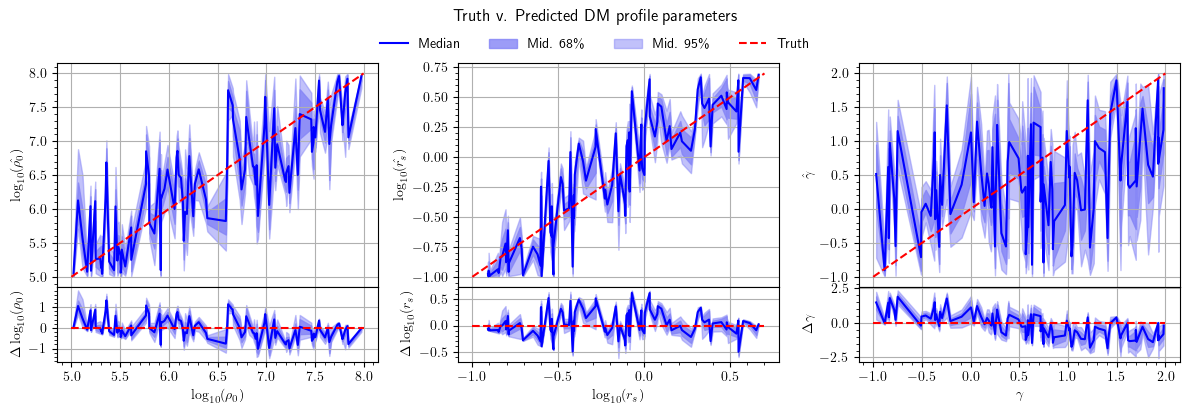

In [ ]:
import matplotlib.pyplot as plt


plt.rcParams["text.usetex"] = True

fig, axs = plt.subplots(2,3, figsize=(12,4), sharex="col", gridspec_kw={'hspace': 0,
                                                                        'height_ratios': [3, 1]})

x_titles = ["$\log_{10}(\\rho _0)$", "$\log_{10}(r_s)$", "$\gamma$"]
y_titles = ["$\log_{10}(\hat{\\rho _0})$", "$\log_{10}(\hat{r_s})$", "$\hat \gamma$"]

dom_min = [5, -1, -1, 0.2]
dom_max = [8, 0.7, 2, 1]

# Top plots
for i, ax in enumerate(axs[0, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    
    # Median
    sim_median = y[2][:,i][index]
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index]
    sim_84 = y[3][:,i][index]
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index]
    sim_97_5 = y[4][:,i][index]
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]

    ax.plot(true_x, true_x, color="red", linestyle = "--", label="Truth")

    # ax.set_xlabel(x_titles[i])
    ax.set_ylabel(y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)

# bottom plots
bottom_y_titles = ["$\Delta \log_{10}(\\rho _0)$", "$\Delta \log_{10}(r_s)$", "$\Delta \gamma$"]
for i, ax in enumerate(axs[1, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    # Median
    sim_median = y[2][:,i][index] - truth
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index] - truth
    sim_84 = y[3][:,i][index] - truth
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index] - truth
    sim_97_5 = y[4][:,i][index] - truth
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]
    true_y = [0,0]

    ax.plot(true_x, true_y, color="red", linestyle = "--", label="Truth")

    ax.set_xlabel(x_titles[i])
    ax.set_ylabel(bottom_y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)



fig.suptitle("Truth v. Predicted DM profile parameters (100 MCMC samples from model trained on 10k galaxies, 100 stars each)", y=1.02)

handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)

)


plt.tight_layout()
plt.show()

### Graphing the Posterior

In [ ]:
k = np.random.randint(0, 10000)

In [ ]:
fig = corner.corner(
    samples[k],
    truths=test_theta[k],
    labels=[r"$\log_{10}(\\rho _0)$", r"\log_{10}(r_s)$", r"$\gamma$"],
    fig=plt.figure(figsize=(8, 8)),
)

In [15]:
test_theta_raw = np.array(pd.read_csv("./data/training_theta(poisson).csv", header=None))
test_x_raw = np.array(pd.read_csv("./data/training_x(poisson).csv", header=None))

test_theta, index = np.unique(test_theta_raw, axis=0, return_index=True)

index = np.sort(index)[:2001]

test_x = np.split(test_x_raw, index, axis=0)[1:2001]

In [20]:
# test_x[0].shape
test_theta_raw.shape

(1002445, 4)